# Day 3 — Bias-Variance & Diagnosing Model Fit

This notebook focuses on diagnosing underfitting and overfitting using training and validation performance.

The experiments demonstrate two approaches to improving model fit: reducing model complexity and applying regularization.




## Step 1 — Import Required Libraries

The required libraries are imported for data loading, data handling, model building, preprocessing, and evaluation.


In [1]:
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso


## Step 2 — Load and Explore the Dataset

The Diabetes dataset provided by Scikit-learn is loaded and converted into a Pandas DataFrame for easier inspection and analysis.

In [2]:
data = load_diabetes()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [19]:
print(df.shape)
df.info()

(442, 11)
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


## Step 3 — Separate Features and Target

The dataset is divided into input features (`X`) and the target variable (`y`).

The **10 features** are used as inputs to the regression models, while the `target` column represents the value that the models will learn to predict.

Keeping the features and target separate is required before splitting the data into training, validation, and test sets.

In [3]:
X = df.drop("target", axis=1)
y = df["target"]

In [4]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (442, 10)
y shape: (442,)


## Step 4 — Train / Validation / Test Split

The dataset is divided into three separate sets: training, validation, and test data.

The training set is used to fit the models, while the validation set is used to diagnose model fit and compare different model configurations.

The test set is kept completely separate during model development and is only used for the final evaluation of the selected model.

The data is split into approximately:

- **60% Training**
- **20% Validation**
- **20% Test**

This prevents the test set from influencing model selection or tuning.

In [5]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

In [7]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (264, 10)
Validation: (89, 10)
Test: (89, 10)


## Step 5 — Deliberately Overfit the Model

To deliberately create an overfitting model, a Decision Tree without a maximum depth limit is used.

Without a depth restriction, the tree can grow very deep and become highly complex, allowing it to learn the training data too closely.

The model is evaluated on both the training and validation sets using R² scores.

We expect an overfitting model to achieve a very high training score while performing considerably worse on the validation set.

In [8]:
overfit_model = DecisionTreeRegressor(
    random_state=42
)

overfit_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [9]:
overfit_train_score = overfit_model.score(X_train, y_train)
overfit_val_score = overfit_model.score(X_val, y_val)

overfit_gap = abs(overfit_train_score - overfit_val_score)

print(f"Train R²: {overfit_train_score:.4f}")
print(f"Validation R²: {overfit_val_score:.4f}")
print(f"Train-Validation Gap: {overfit_gap:.4f}")

Train R²: 1.0000
Validation R²: 0.2095
Train-Validation Gap: 0.7905


### Overfitting Diagnosis

The model achieved a Training R² score of **1.0000** and a Validation R² score of **0.2095**.

The training score is extremely high, while the validation score is considerably lower. This resulted in a large train-validation gap of **0.7905**.

This indicates that the model has learned the training data too closely and does not generalize well to unseen validation data.

Therefore, this model demonstrates **overfitting (high variance)**.

- Training R²: **1.0000**
- Validation R²: **0.2095**
- Train-Validation Gap: **0.7905**

The large difference between the training and validation scores provides clear evidence of overfitting.

## Step 6 — Deliberately Underfit the Model

To deliberately create an underfitting model, a Decision Tree with a very small `max_depth` is used.

A shallow tree has limited complexity and may not be able to capture the underlying patterns in the training data.

The model is evaluated on both the training and validation sets using R² scores.

We expect an underfitting model to have relatively low performance on both datasets.

In [10]:
underfit_model = DecisionTreeRegressor(
    max_depth=1,
    random_state=42
)

In [11]:
underfit_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [12]:
underfit_train_score = underfit_model.score(X_train, y_train)
underfit_val_score = underfit_model.score(X_val, y_val)

underfit_gap = abs(underfit_train_score - underfit_val_score)

print(f"Train R²: {underfit_train_score:.4f}")
print(f"Validation R²: {underfit_val_score:.4f}")
print(f"Train-Validation Gap: {underfit_gap:.4f}")

Train R²: 0.3163
Validation R²: 0.2233
Train-Validation Gap: 0.0930


### Underfitting Diagnosis

The model achieved a Training R² score of **0.3163** and a Validation R² score of **0.2233**.

Both scores are relatively low, indicating that the model is not complex enough to capture the underlying patterns in the data.

The train-validation gap is only **0.0930**, which is much smaller than the gap observed in the overfitted model.

Therefore, this model demonstrates **underfitting (high bias)**.

- Training R²: **0.3163**
- Validation R²: **0.2233**
- Train-Validation Gap: **0.0930**

This confirms the expected symptom of underfitting: **low training and validation performance**.

## Step 7 — Fixing Overfitting by Reducing Model Complexity

The overfitted Decision Tree was too complex and achieved a very high training score while performing much worse on the validation set.

To reduce overfitting, the model complexity is reduced by limiting the tree's maximum depth to **5**.

The goal is to reduce the train-validation gap and improve the model's ability to generalize to unseen data.

This approach follows the principle that reducing model complexity can reduce variance and help control overfitting.

In [13]:
fixed_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)
fixed_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [ ]:
fixed_train_score = fixed_model.score(X_train, y_train)
fixed_val_score = fixed_model.score(X_val, y_val)

fixed_gap = abs(fixed_train_score - fixed_val_score)

print(f"Train R²: {fixed_train_score:.4f}")
print(f"Validation R²: {fixed_val_score:.4f}")
print(f"Train-Validation Gap: {fixed_gap:.4f}")

Train R²: 0.6722
Validation R²: 0.3551
Train-Validation Gap: 0.3172


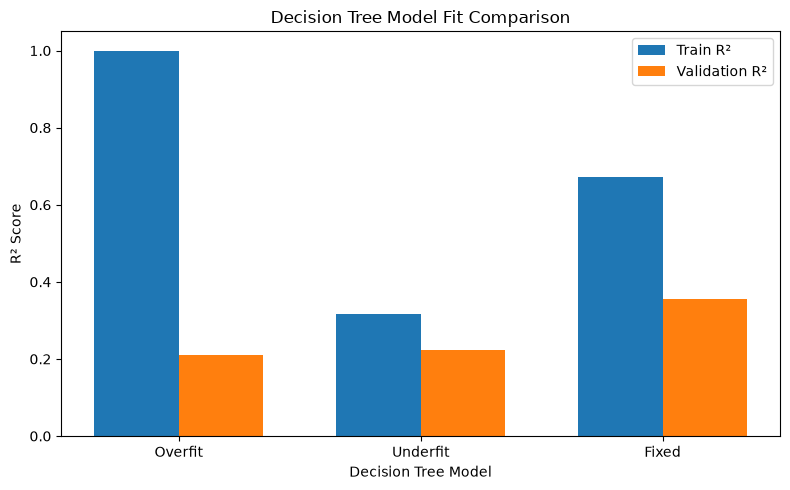

In [15]:
import matplotlib.pyplot as plt
import numpy as np

models = [
    "Overfit",
    "Underfit",
    "Fixed"
]

train_scores = [
    overfit_train_score,
    underfit_train_score,
    fixed_train_score
]

val_scores = [
    overfit_val_score,
    underfit_val_score,
    fixed_val_score
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, train_scores, width, label="Train R²")
plt.bar(x + width/2, val_scores, width, label="Validation R²")

plt.ylabel("R² Score")
plt.xlabel("Decision Tree Model")
plt.title("Decision Tree Model Fit Comparison")

plt.xticks(x, models)
plt.legend()

plt.tight_layout()
plt.show()

### Overfitting Fix Diagnosis

After limiting the Decision Tree to a maximum depth of **5**, the Training R² score decreased to **0.6722**, while the Validation R² score increased to **0.3551**.

The train-validation gap decreased from **0.7905** in the overfitted model to **0.3171**.

This indicates that reducing the model's complexity successfully reduced overfitting and improved generalization.

- Training R²: **0.6722**
- Validation R²: **0.3551**
- Train-Validation Gap: **0.3171**
- Previous Overfit Gap: **0.7905**

Although the training score decreased, this is expected when reducing model complexity. The important result is that the validation performance improved and the train-validation gap became significantly smaller.

### Applying Both Approaches to Fix Overfitting

The overfitting problem can be addressed in two different ways.

First, the complexity of the Decision Tree was reduced by limiting its maximum depth. This successfully reduced the train-validation gap and improved validation performance.

To further demonstrate the second approach mentioned in the lab, regularization will also be applied to a more complex linear model.

For this purpose, Polynomial Regression is used to introduce additional model complexity, followed by Ridge and Lasso regularization to control that complexity.

This allows both approaches to be demonstrated:

- **Reducing model complexity:** Limiting the Decision Tree's `max_depth`.
- **Applying regularization:** Using Ridge (L2) and Lasso (L1) on Polynomial Regression.

The results of both approaches will be compared based on their training performance, validation performance, and train-validation gap.

## Step 8 — Polynomial Regression Baseline

Initially, regularization was tested with Linear Regression, but the results did not show a significant change.

Therefore, Polynomial Regression was introduced to increase model complexity before applying regularization. Polynomial features add higher-order terms and interactions between features, making the model more complex and providing a clearer setting to demonstrate the effect of regularization.

A degree-2 polynomial model without regularization is used as the baseline. Its performance is then compared with Ridge and Lasso regularized versions.

In [16]:
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("model", LinearRegression())
])
poly_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'s4','s5','s6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [17]:
poly_train_score = poly_model.score(X_train, y_train)
poly_val_score = poly_model.score(X_val, y_val)

poly_gap = abs(poly_train_score - poly_val_score)

print(f"Train R²: {poly_train_score:.4f}")
print(f"Validation R²: {poly_val_score:.4f}")
print(f"Train-Validation Gap: {poly_gap:.4f}")

Train R²: 0.6278
Validation R²: 0.3602
Train-Validation Gap: 0.2676


### Polynomial Regression Baseline Results

The Polynomial Regression model achieved a Training R² score of **0.6278** and a Validation R² score of **0.3602**.

The train-validation gap was **0.2676**, indicating a noticeable difference between training and validation performance.

The higher training performance compared with the validation performance suggests that the increased complexity of the polynomial model has introduced some overfitting.

This model will serve as the baseline for testing whether Ridge and Lasso regularization can reduce the train-validation gap and improve generalization.

## Step 9 — Polynomial Regression with Ridge Regularization

Ridge regularization is applied to the Polynomial Regression model.

The polynomial features increase model complexity, while StandardScaler is used to standardize the generated features before applying Ridge regularization.

Ridge uses L2 regularization to penalize large coefficients and control model complexity.

The goal is to reduce overfitting, decrease the train-validation gap, and improve validation performance compared with the unregularized Polynomial Regression baseline.

In [18]:
poly_ridge_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

In [19]:
poly_ridge_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'s4','s5','s6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [20]:
poly_ridge_train_score = poly_ridge_model.score(X_train, y_train)
poly_ridge_val_score = poly_ridge_model.score(X_val, y_val)

poly_ridge_gap = abs (
    poly_ridge_train_score - poly_ridge_val_score
)

print(f"Train R²: {poly_ridge_train_score:.4f}")
print(f"Validation R²: {poly_ridge_val_score:.4f}")
print(f"Train-Validation Gap: {poly_ridge_gap:.4f}")

Train R²: 0.6165
Validation R²: 0.4217
Train-Validation Gap: 0.1948


### Ridge Regularization Results

The Polynomial Regression model with Ridge regularization achieved a Training R² score of **0.6165** and a Validation R² score of **0.4217**.

The train-validation gap was **0.1948**.

Compared with the unregularized Polynomial Regression model, the Validation R² improved from **0.3602** to **0.4217**, while the train-validation gap decreased from **0.2676** to **0.1948**.

These results show that Ridge regularization reduced the effect of the increased model complexity and improved generalization on the validation set.


## Step 10 — Polynomial Regression with Lasso Regularization

Lasso regularization is applied to the same Polynomial Regression model.

Lasso uses L1 regularization to penalize the absolute values of the model coefficients. It can also shrink some coefficients to exactly zero.

The goal is to control the increased complexity introduced by the polynomial features, reduce overfitting, and improve generalization.

The results are compared with the unregularized Polynomial Regression baseline and the Ridge regularized model.

In [21]:
poly_lasso_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1, max_iter=10000))
])

In [22]:
poly_lasso_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('poly', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'s4','s5','s6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [23]:
poly_lasso_train_score = poly_lasso_model.score(X_train, y_train)
poly_lasso_val_score = poly_lasso_model.score(X_val, y_val)

poly_lasso_gap = abs(
    poly_lasso_train_score - poly_lasso_val_score
)

print(f"Train R²: {poly_lasso_train_score:.4f}")
print(f"Validation R²: {poly_lasso_val_score:.4f}")
print(f"Train-Validation Gap: {poly_lasso_gap:.4f}")

Train R²: 0.6148
Validation R²: 0.4144
Train-Validation Gap: 0.2004


### Lasso Regularization Results

The Polynomial Regression model with Lasso regularization achieved a Training R² score of **0.6148** and a Validation R² score of **0.4144**.

The train-validation gap was **0.2004**.

Compared with the unregularized Polynomial Regression model, the Validation R² improved from **0.3602** to **0.4144**, while the train-validation gap decreased from **0.2676** to **0.2004**.

These results show that Lasso regularization reduced the effect of the increased model complexity and improved generalization on the validation set.

Among the two regularized polynomial models, Ridge achieved a slightly higher Validation R² score than Lasso.


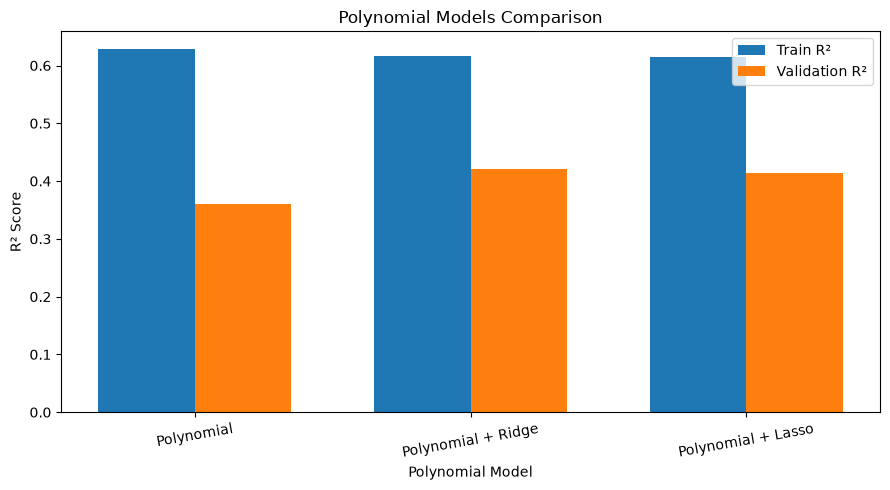

In [24]:
models = [
    "Polynomial",
    "Polynomial + Ridge",
    "Polynomial + Lasso"
]

train_scores = [
    poly_train_score,
    poly_ridge_train_score,
    poly_lasso_train_score
]

val_scores = [
    poly_val_score,
    poly_ridge_val_score,
    poly_lasso_val_score
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(x - width/2, train_scores, width, label="Train R²")
plt.bar(x + width/2, val_scores, width, label="Validation R²")

plt.ylabel("R² Score")
plt.xlabel("Polynomial Model")
plt.title("Polynomial Models Comparison")

plt.xticks(x, models, rotation=10)
plt.legend()

plt.tight_layout()
plt.show()

## Step 11 — Model Fit Comparison

The results from all experiments are compared using the training R² score, validation R² score, and the absolute train-validation gap.

The train-validation gap is calculated as the absolute difference between the training and validation scores. A large gap can indicate overfitting, while a small gap indicates that the model performs similarly on both datasets.

This comparison helps identify how model complexity and regularization affected model generalization.

In [42]:
results = pd.DataFrame({
    "Model": [
        "Overfit Decision Tree",
        "Underfit Decision Tree",
        "Fixed Decision Tree",
        "Polynomial Regression",
        "Polynomial + Ridge",
        "Polynomial + Lasso"
    ],
    "Train R²": [
        overfit_train_score,
        underfit_train_score,
        fixed_train_score,
        poly_train_score,
        poly_ridge_train_score,
        poly_lasso_train_score
    ],
    "Validation R²": [
        overfit_val_score,
        underfit_val_score,
        fixed_val_score,
        poly_val_score,
        poly_ridge_val_score,
        poly_lasso_val_score
    ],
    "Train-Validation Gap": [
        overfit_gap,
        underfit_gap,
        fixed_gap,
        poly_gap,
        poly_ridge_gap,
        poly_lasso_gap
    ]
})

results

,Model,Train R²,Validation R²,Train-Validation Gap
0,Overfit Decision Tree,1.000000,0.209538,0.790462
1,Underfit Decision Tree,0.316333,0.223299,0.093034
2,Fixed Decision Tree,0.672237,0.355059,0.317178
3,Polynomial Regression,0.627777,0.360201,0.267576
4,Polynomial + Ridge,0.616509,0.421726,0.194784
5,Polynomial + Lasso,0.614835,0.414445,0.200390


### Model Fit Comparison

The comparison shows clear differences between underfitting, overfitting, and regularized models.

The overfit Decision Tree achieved a perfect Training R² of **1.0000**, but its Validation R² was only **0.2095**, resulting in the largest train-validation gap of **0.7905**. This clearly demonstrates overfitting.

The underfit Decision Tree had relatively low Training and Validation R² scores of **0.3163** and **0.2233**, respectively, indicating that the model was too simple to capture the underlying patterns.

Reducing the tree depth improved the Validation R² from **0.2095** to **0.3551** and reduced the gap from **0.7905** to **0.3172**, demonstrating that reducing model complexity helped control overfitting.

For the polynomial models, the unregularized Polynomial Regression achieved a Validation R² of **0.3602** with a gap of **0.2676**.

Applying Ridge regularization improved the Validation R² to **0.4217** and reduced the train-validation gap to **0.1948**.

Lasso also improved the Validation R² to **0.4144** and reduced the train-validation gap to **0.2004**.

Among the regularized polynomial models, **Ridge achieved the highest Validation R² of 0.4217**, while both Ridge and Lasso reduced the train-validation gap compared with the unregularized Polynomial Regression.

Overall, the results demonstrate that reducing model complexity or applying regularization can reduce overfitting and improve generalization.


## Step 12 — Final Test Evaluation

After comparing the models using the validation set, **Ridge achieved the highest validation R² score of 0.4217** among the regularized polynomial models. Therefore, the Polynomial Regression model with Ridge regularization was selected as the final model.

The test set was kept completely separate throughout the model development process and was not used for model selection or tuning.

The selected **Polynomial + Ridge** model was then evaluated on the unseen test set to estimate its final generalization performance.

In [29]:
final_model = poly_ridge_model 
test_score = final_model.score(X_test, y_test) 
print(f"Final Test R²: {test_score:.4f}")

Final Test R²: 0.3750


### Final Test Results

The selected model achieved a final Test R² score of **0.3750**.

The model's performance on the unseen test set was lower than its validation performance. This difference is expected because the test set contains data that was not used during model selection.

The positive Test R² indicates that the model was able to explain a meaningful portion of the variation in the target values.

The test set was used only for the final evaluation, providing an estimate of how well the selected model generalizes to unseen data.


## Conclusion

This experiment demonstrated how to diagnose and address different types of model fit using training and validation performance.

The overfit Decision Tree achieved a Training R² of **1.0000** and a Validation R² of **0.2095**, resulting in a large train-validation gap of **0.7905**. This clearly demonstrated overfitting and high variance.

The underfit Decision Tree achieved relatively low Training and Validation R² scores of **0.3163** and **0.2233**, respectively. This demonstrated underfitting and high bias because the model was too simple to capture the underlying patterns in the data.

To address the overfitting problem, the Decision Tree complexity was reduced by limiting its `max_depth` to **5**. This improved the Validation R² from **0.2095** to **0.3551** and reduced the train-validation gap from **0.7905** to **0.3172**. This showed that reducing model complexity can reduce overfitting and improve generalization.

Regularization was also explored as a second approach to controlling model complexity. Initially, Ridge and Lasso were tested with Linear Regression, but the results did not show a significant change. Therefore, Polynomial Regression with `degree=2` was introduced to increase model complexity and provide a clearer setting for demonstrating the effect of regularization.

The unregularized Polynomial Regression achieved a Training R² of **0.6278**, a Validation R² of **0.3602**, and a train-validation gap of **0.2676**.

Ridge regularization was then applied using L2 regularization. The model achieved a Validation R² of **0.4217** and reduced the train-validation gap to **0.1948**. This showed improved validation performance and reduced overfitting compared with the unregularized Polynomial Regression.

Lasso regularization was also applied using L1 regularization. It achieved a Validation R² of **0.4144** and a train-validation gap of **0.2004**. Lasso also improved the validation performance and reduced the gap compared with the unregularized polynomial model.

Among the regularized polynomial models, **Ridge achieved the highest Validation R² of 0.4217**, slightly outperforming Lasso.

Finally, the selected model was evaluated on the unseen test set. The final model achieved a **Test R² of 0.3910**. The test set was kept separate during model development and was used only for the final evaluation.

Overall, the experiment demonstrated the bias-variance trade-off and two approaches to controlling overfitting: **reducing model complexity** and **applying regularization**. The results showed that controlling model complexity can reduce the train-validation gap and improve the model's ability to generalize to unseen data.